In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Dataset path
dataset_path = "/content/drive/MyDrive/Oral_cancer/First Set"
normal_path = os.path.join(dataset_path, "100x Normal Oral Cavity Histopathological Images")
oscc_path = os.path.join(dataset_path, "100x OSCC Histopathological Images")

print("Normal Path Exists:", os.path.exists(normal_path))
print("OSCC Path Exists:", os.path.exists(oscc_path))




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Normal Path Exists: True
OSCC Path Exists: True


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 160

def load_images(folder, label):
    images, labels = [], []
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0  # Normalize
            images.append(img)
            labels.append(label)
    return images, labels

normal_images, normal_labels = load_images(normal_path, 0)
oscc_images, oscc_labels = load_images(oscc_path, 1)

X_normal = np.array(normal_images)
y_normal = np.array(normal_labels)
X_oscc = np.array(oscc_images)
y_oscc = np.array(oscc_labels)

print("Normal Images:", X_normal.shape)
print("OSCC Images:", X_oscc.shape)


Normal Images: (89, 160, 160, 3)
OSCC Images: (439, 160, 160, 3)


In [ ]:
from imblearn.over_sampling import SMOTE

X_combined = np.concatenate((X_normal, X_oscc), axis=0)
y_combined = np.concatenate((y_normal, y_oscc), axis=0)

# Flatten for SMOTE
X_flat = X_combined.reshape((X_combined.shape[0], -1))
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_combined)

# Reshape back
X_resampled = X_resampled.reshape((-1, IMG_SIZE, IMG_SIZE, 3))

print("Balanced Distribution:", np.bincount(y_resampled))


Balanced Distribution: [439 439]


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow(X_train, y_train, batch_size=32)
val_generator = datagen.flow(X_val, y_val, batch_size=32)


Train: 702 Val: 88 Test: 88


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Capsule Squash Function
def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm)
    return scale * vectors / tf.sqrt(s_squared_norm + tf.keras.backend.epsilon())

# Length layer for CapsuleNet
class Length(layers.Layer):
    def call(self, inputs, **kwargs):
        return tf.sqrt(tf.reduce_sum(tf.square(inputs), axis=-1) + tf.keras.backend.epsilon())

# Build Model
def CapsNetModel(input_shape=(160, 160, 3), n_class=2, routings=3):
    inputs = tf.keras.Input(shape=input_shape)

    # MobileNetV2 Backbone
    base_model = MobileNetV2(include_top=False, input_shape=input_shape, weights='imagenet')
    base_model.trainable = False
    x = base_model(inputs, training=False)

    x = layers.Conv2D(256, kernel_size=1, activation='relu')(x)
    x = layers.Conv2D(32 * 8, kernel_size=3, padding='valid', activation='relu')(x)
    x = layers.Reshape([-1, 8])(x)
    x = layers.Lambda(squash)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(n_class * 16, activation='relu')(x)
    digit_caps = layers.Reshape((n_class, 16))(x)

    out_caps = Length(name='capsnet_output')(digit_caps)
    model = models.Model(inputs, out_caps, name='CapsNet')
    return model

model = CapsNetModel()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "CapsNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 5, 5, 256)           │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 3, 3, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_4 (Reshape)                  │ (None, 288, 8)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_4 (Lambda)                    │ (None, 288, 8)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 8)                   │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_5 (Reshape)                  │ (None, 2, 16)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ capsnet_output (Length)              │ (None, 2)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,176,288 (12.12 MB)

 Trainable params: 918,304 (3.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    batch_size=32
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6212 - loss: 0.6458 - val_accuracy: 0.8864 - val_loss: 0.4322
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8466 - loss: 0.4587 - val_accuracy: 0.8750 - val_loss: 0.2970
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9104 - loss: 0.3109 - val_accuracy: 0.8977 - val_loss: 0.3155
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9144 - loss: 0.2444 - val_accuracy: 0.8977 - val_loss: 0.2635
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8964 - loss: 0.2148 - val_accuracy: 0.9318 - val_loss: 0.1735
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9215 - loss: 0.2008 - val_accuracy: 0.8977 - val_loss: 0.3279
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9482 - loss: 0.1421 - val_accuracy: 0.9091 - val_loss: 0.3378
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9448 - loss: 0.1308 - val_accuracy: 0.9318 - val_loss:

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9734 - loss: 0.0586
Test Accuracy: 95.45%


In [ ]:
# Save your trained CapsNet model
model.save('/content/drive/MyDrive/OSCC_CapsNet/OSCC_CapsNet_model.h5')
print("✅ Model saved successfully.")


✅ Model saved successfully.


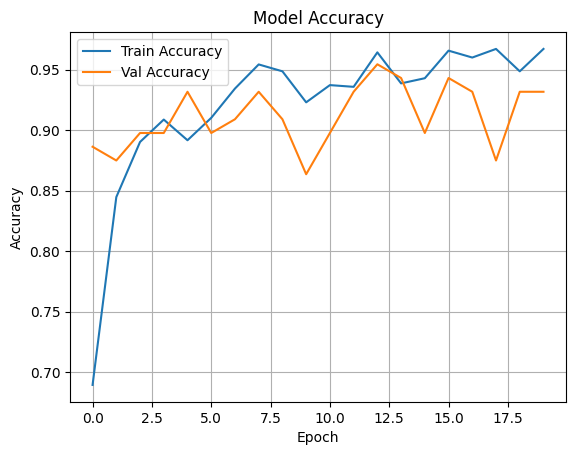

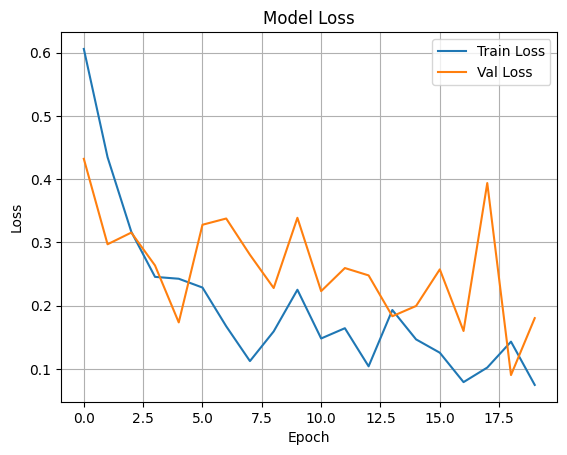

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step


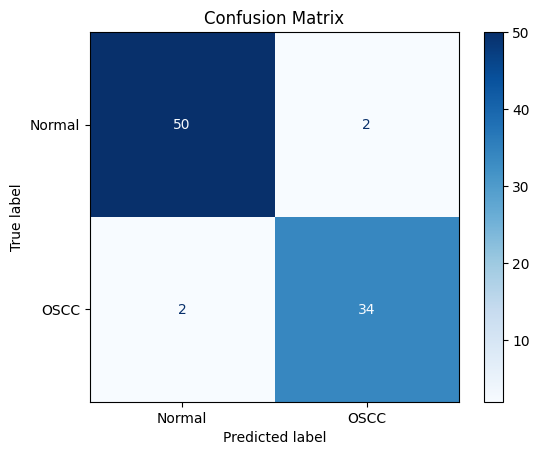

Classification Report:

              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96        52
        OSCC       0.94      0.94      0.94        36

    accuracy                           0.95        88
   macro avg       0.95      0.95      0.95        88
weighted avg       0.95      0.95      0.95        88



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred_probs = model.predict(X_test)
y_pred = tf.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'OSCC'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'OSCC']))


<ipython-input-27-c0cdd81f98a1>:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray')


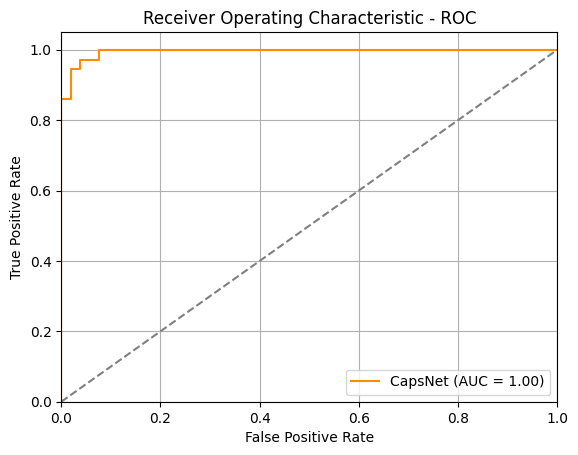

In [ ]:
from sklearn.metrics import roc_curve, auc

y_probs = y_pred_probs[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='CapsNet (AUC = {:.2f})'.format(roc_auc), color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', color='gray')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# Custom objects used (Length layer + squash)
def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm)
    return scale * vectors / tf.sqrt(s_squared_norm + tf.keras.backend.epsilon())

class Length(tf.keras.layers.Layer):
    def call(self, inputs, **kwargs):
        return tf.sqrt(tf.reduce_sum(tf.square(inputs), axis=-1) + tf.keras.backend.epsilon())

# Load model
model = load_model(
    '/content/drive/MyDrive/OSCC_CapsNet/OSCC_CapsNet_model.h5',
    custom_objects={'Length': Length, 'squash': squash}
)

print("Model loaded successfully!")


In [ ]:
# Print all layer names to confirm structure
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name}")


0: input_layer_6
1: mobilenetv2_1.00_160
2: conv2d_6
3: conv2d_7
4: reshape_4
5: lambda_4
6: global_average_pooling1d
7: dense
8: reshape_5
9: capsnet_output


In [ ]:
mobilenet = model.get_layer("mobilenetv2_1.00_160")
for i, layer in enumerate(mobilenet.layers):
    print(i, layer.name)


0 input_layer_7
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_rel

In [ ]:
pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c818e2382f5481415706a0b186938ef500d14b5933fee9c6332859838349e730
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 890ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

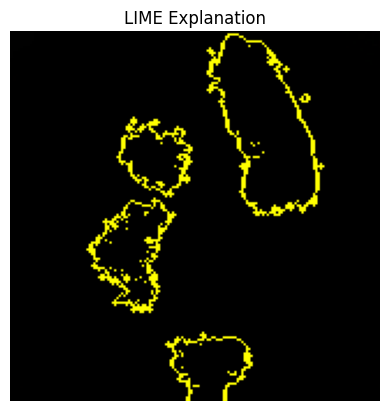

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image=np.squeeze(img_array),  # input image
    classifier_fn=lambda x: model.predict(x),  # your model
    top_labels=2,
    hide_color=0,
    num_samples=1000  # higher = better
)

from matplotlib import pyplot as plt

# Show explanation for top class
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation")
plt.axis('off')
plt.show()


In [ ]:
pip install lime scikit-image


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

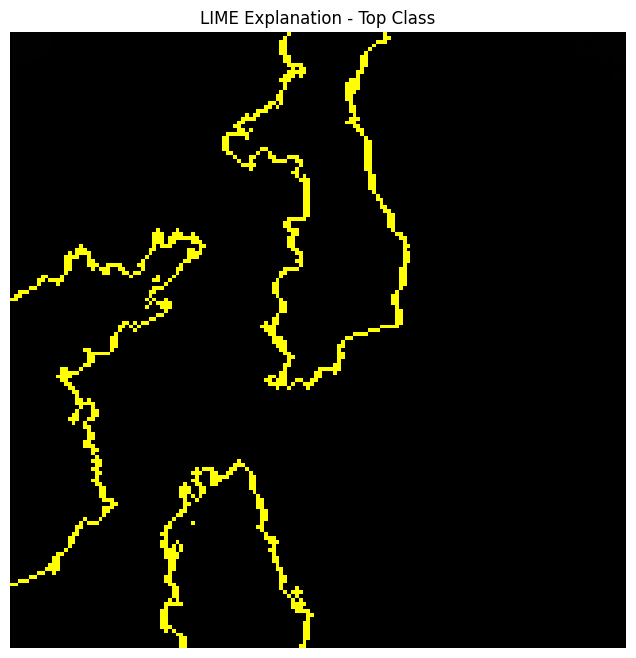

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from lime import lime_image
from PIL import Image
import cv2

# Load and preprocess your image
img_path = "/content/drive/MyDrive/Oral_cancer/First Set/100x OSCC Histopathological Images/OSCC_100x_9.jpg"
img = Image.open(img_path).resize((160, 160))
img = np.array(img)

# Normalize same way as model input
img_norm = img / 255.0
img_input = np.expand_dims(img_norm, axis=0)

# Initialize the LIME image explainer
explainer = lime_image.LimeImageExplainer()

# Explain the model prediction
explanation = explainer.explain_instance(
    image=img_norm,  # must be (H, W, C)
    classifier_fn=lambda x: model.predict(x),
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

# Visualize explanation for top predicted class
from skimage.color import label2rgb
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

# Show LIME output
plt.figure(figsize=(8, 8))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation - Top Class")
plt.axis('off')
plt.show()


In [ ]:
for layer in mobilenet_model.layers:
    try:
        print(f"{layer.name}: {layer.output.shape}")
    except:
        print(f"{layer.name}: (no output shape)")


input_layer_7: (None, 160, 160, 3)
Conv1: (None, 80, 80, 32)
bn_Conv1: (None, 80, 80, 32)
Conv1_relu: (None, 80, 80, 32)
expanded_conv_depthwise: (None, 80, 80, 32)
expanded_conv_depthwise_BN: (None, 80, 80, 32)
expanded_conv_depthwise_relu: (None, 80, 80, 32)
expanded_conv_project: (None, 80, 80, 16)
expanded_conv_project_BN: (None, 80, 80, 16)
block_1_expand: (None, 80, 80, 96)
block_1_expand_BN: (None, 80, 80, 96)
block_1_expand_relu: (None, 80, 80, 96)
block_1_pad: (None, 81, 81, 96)
block_1_depthwise: (None, 40, 40, 96)
block_1_depthwise_BN: (None, 40, 40, 96)
block_1_depthwise_relu: (None, 40, 40, 96)
block_1_project: (None, 40, 40, 24)
block_1_project_BN: (None, 40, 40, 24)
block_2_expand: (None, 40, 40, 144)
block_2_expand_BN: (None, 40, 40, 144)
block_2_expand_relu: (None, 40, 40, 144)
block_2_depthwise: (None, 40, 40, 144)
block_2_depthwise_BN: (None, 40, 40, 144)
block_2_depthwise_relu: (None, 40, 40, 144)
block_2_project: (None, 40, 40, 24)
block_2_project_BN: (None, 40, 40

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# Step 1: Define Input
input_shape = (160, 160, 3)
inputs = Input(shape=input_shape)

# Step 2: Load Base MobileNetV2 with Imagenet Weights
# We set include_top=False to remove classification head
base_model = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet')

# Step 3: Choose an Intermediate Layer to Extract Features From
# You can print layer names to verify (done below)
# We're using "block_13_expand_relu" as it exists in all MobileNetV2 variants
intermediate_layer = base_model.get_layer("block_13_expand_relu").output

# Step 4: Create Feature Extractor Model
feature_extractor = Model(inputs=base_model.input, outputs=intermediate_layer)
feature_extractor.trainable = False  # Optional: Freeze if using for feature extraction

# Step 5: (Optional) Print the Summary
feature_extractor.summary()

# Now you can use `feature_extractor` to extract features from any image


<ipython-input-84-a67d3b48e8a1>:11: UserWarning:

`input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12            │ (None, 160, 160, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 80, 80, 32)     │            864 │ input_layer_12[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 80, 80, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 80, 80, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 80, 80, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 80, 80, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 80, 80, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 80, 80, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 80, 80, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 80, 80, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 80, 80, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 80, 80, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 81, 81, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 40, 40, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 616,256 (2.35 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 616,256 (2.35 MB)

In [ ]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name)


0 input_layer_12
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_re

In [ ]:
model.summary()

Model: "CapsNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 5, 5, 256)           │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 3, 3, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_4 (Reshape)                  │ (None, 288, 8)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_4 (Lambda)                    │ (None, 288, 8)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 8)                   │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_5 (Reshape)                  │ (None, 2, 16)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ capsnet_output (Length)              │ (None, 2)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,176,290 (12.12 MB)

 Trainable params: 918,304 (3.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


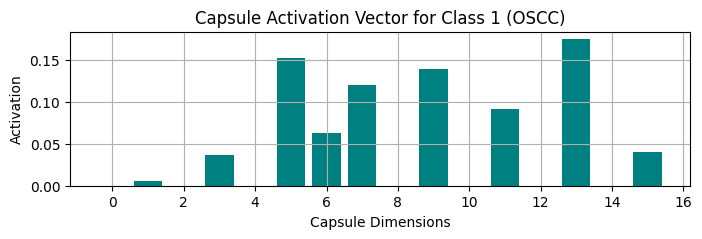

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
import tensorflow as tf

# 🔍 Sub-model to extract capsule outputs (before Length layer)
caps_output_model = Model(inputs=model.input,
                          outputs=model.get_layer('reshape_5').output)

# 🔄 Preprocess input image
def preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(160, 160))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# 🧪 Predict and visualize
img_array = preprocess_image('/content/drive/MyDrive/Oral_cancer/First Set/100x OSCC Histopathological Images/OSCC_100x_9.jpg')  # update path
caps_output = caps_output_model.predict(img_array)  # Shape: (1, 2, 16)

# 🎯 Choose which class to visualize: 0 = Normal, 1 = OSCC
class_idx = 1
caps_vector = caps_output[0, class_idx, :]  # shape: (16,)

plt.figure(figsize=(8, 2))
plt.bar(np.arange(16), caps_vector, color='teal')
plt.title(f"Capsule Activation Vector for Class {class_idx} ({'OSCC' if class_idx == 1 else 'Normal'})")
plt.xlabel("Capsule Dimensions")
plt.ylabel("Activation")
plt.grid(True)
plt.show()


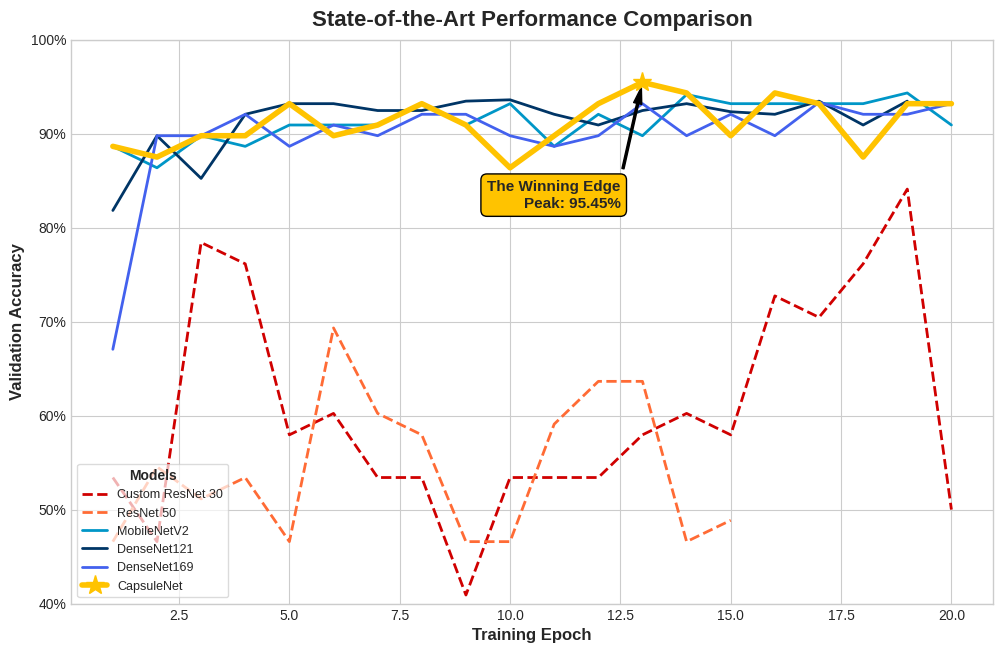

<ipython-input-12-1447719593>:131: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_summary['Model'], rotation=45, ha="right", fontsize=10)


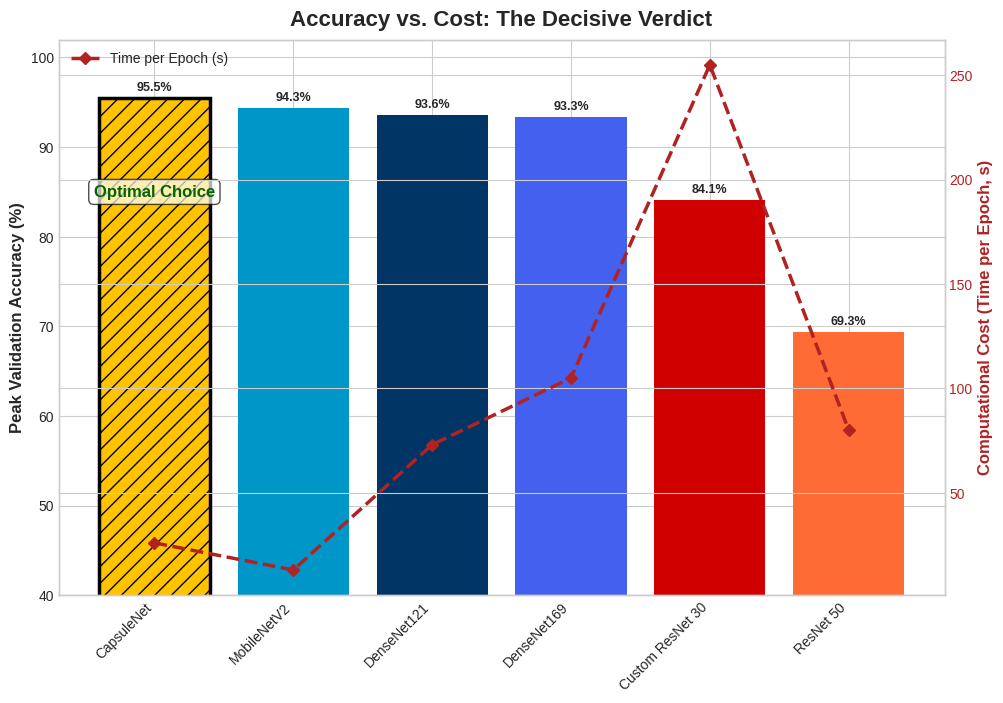

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker

# ==============================================================================
# MODEL PERFORMANCE DATA (Val Accuracy per Epoch + Avg Epoch Time in Seconds)
# ==============================================================================
model_data = {
    'Custom ResNet 30': {
        'val_accuracy': [0.5341, 0.4659, 0.7841, 0.7614, 0.5795, 0.6023, 0.5341, 0.5341, 0.4091, 0.5341,
                         0.5341, 0.5341, 0.5795, 0.6023, 0.5795, 0.7273, 0.7045, 0.7614, 0.8409, 0.5000],
        'avg_epoch_time': 255},
    'ResNet 50': {
        'val_accuracy': [0.4659, 0.5455, 0.5114, 0.5341, 0.4659, 0.6932, 0.6023, 0.5795, 0.4659, 0.4659,
                         0.5909, 0.6364, 0.6364, 0.4659, 0.4886],
        'avg_epoch_time': 80},
    'MobileNetV2': {
        'val_accuracy': [0.8864, 0.8636, 0.8977, 0.8864, 0.9091, 0.9091, 0.9091, 0.9318, 0.9091, 0.9318,
                         0.8864, 0.9205, 0.8977, 0.9415, 0.9318, 0.9318, 0.9318, 0.9318, 0.9432, 0.9091],
        'avg_epoch_time': 13},
    'DenseNet121': {
        'val_accuracy': [0.8182, 0.8977, 0.8523, 0.9205, 0.9318, 0.9318, 0.9245, 0.9245, 0.9345, 0.9359,
                         0.9205, 0.9091, 0.9245, 0.9318, 0.9232, 0.9205, 0.9345, 0.9091, 0.9345],
        'avg_epoch_time': 73},
    'DenseNet169': {
        'val_accuracy': [0.6705, 0.8977, 0.8977, 0.9205, 0.8864, 0.9091, 0.8977, 0.9205, 0.9205, 0.8977,
                         0.8864, 0.8977, 0.9318, 0.8977, 0.9205, 0.8977, 0.9332, 0.9205, 0.9205, 0.9318],
        'avg_epoch_time': 105},
    'CapsuleNet': {
        'val_accuracy': [0.8864, 0.8750, 0.8977, 0.8977, 0.9318, 0.8977, 0.9091, 0.9318, 0.9091, 0.8636,
                         0.8977, 0.9318, 0.9545, 0.9432, 0.8977, 0.9432, 0.9318, 0.8750, 0.9318, 0.9318],
        'avg_epoch_time': 26}
}

# ==============================================================================
# COMMON STYLING CONFIGURATION
# ==============================================================================
colors = {
    'CapsuleNet': '#FFC300',
    'DenseNet121': '#003566',
    'DenseNet169': '#4361EE',
    'MobileNetV2': '#0096C7',
    'Custom ResNet 30': '#D00000',
    'ResNet 50': '#FF6B35',
}
linewidths = {'CapsuleNet': 4.0, 'default': 2.0}
zorders = {'CapsuleNet': 10, 'default': 1}

plt.style.use('seaborn-v0_8-whitegrid')

# ==============================================================================
# GRAPH 1: PERFORMANCE OVER EPOCHS
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6.5))

for name, data in model_data.items():
    ax.plot(
        range(1, len(data['val_accuracy']) + 1),
        data['val_accuracy'],
        label=name,
        color=colors.get(name),
        linestyle='--' if 'ResNet' in name else '-',
        linewidth=linewidths.get(name, linewidths['default']),
        marker='*' if name == 'CapsuleNet' else '',
        markersize=14,
        markevery=[np.argmax(data['val_accuracy'])] if name == 'CapsuleNet' else [],
        zorder=zorders.get(name, zorders['default'])
    )

# Annotate CapsuleNet peak
peak_acc = max(model_data['CapsuleNet']['val_accuracy'])
peak_epoch = np.argmax(model_data['CapsuleNet']['val_accuracy']) + 1
ax.annotate(
    f'The Winning Edge\nPeak: {peak_acc:.2%}',
    xy=(peak_epoch, peak_acc),
    xytext=(peak_epoch - 0.5, peak_acc - 0.12),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
    ha='right', va='center', fontsize=11, fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.4", fc=colors['CapsuleNet'], ec="k", lw=1)
)

# Labels and title
ax.set_title('State-of-the-Art Performance Comparison', fontsize=16, fontweight='bold', pad=10)
ax.set_xlabel('Training Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_ylim(0.4, 1.0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

# Legend inside plot
legend = ax.legend(
    loc='lower left', fontsize=9,
    title='Models', title_fontsize='10',
    frameon=True, facecolor='white', framealpha=0.7
)
plt.setp(legend.get_title(), fontweight='bold')

fig.tight_layout(pad=0.5)
plt.show()

# ==============================================================================
# GRAPH 2: PEAK ACCURACY VS EPOCH TIME (COST)
# ==============================================================================
# Prepare summary data
summary_data = [
    {
        'Model': name,
        'Best Val Accuracy': max(data['val_accuracy']) * 100,
        'Avg Epoch Time (s)': data['avg_epoch_time']
    }
    for name, data in model_data.items()
]
df_summary = pd.DataFrame(summary_data).sort_values('Best Val Accuracy', ascending=False)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 7))

# Bar chart (Accuracy)
bar_colors = [colors.get(model) for model in df_summary['Model']]
bars = ax1.bar(
    df_summary['Model'],
    df_summary['Best Val Accuracy'],
    color=bar_colors,
    zorder=2
)

# Accuracy axis setup
ax1.set_ylabel('Peak Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelsize=10)
ax1.set_xticklabels(df_summary['Model'], rotation=45, ha="right", fontsize=10)
ax1.set_ylim(40, 102)

# Accuracy value labels
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# Line chart (Epoch Time)
ax2 = ax1.twinx()
ax2.plot(
    df_summary['Model'],
    df_summary['Avg Epoch Time (s)'],
    color='#B22222', marker='D', markersize=6,
    linestyle='--', linewidth=2.5, label='Time per Epoch (s)'
)
ax2.set_ylabel('Computational Cost (Time per Epoch, s)', color='#B22222', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#B22222', labelsize=10)

# Highlight CapsuleNet
capsule_index = list(df_summary['Model']).index('CapsuleNet')
bars[capsule_index].set_edgecolor('black')
bars[capsule_index].set_linewidth(2.5)
bars[capsule_index].set_hatch('//')
ax1.text(
    capsule_index, 85, 'Optimal Choice',
    ha='center', va='center', fontsize=12, fontweight='bold', color='darkgreen',
    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3')
)

# Titles and legend
ax1.set_title('Accuracy vs. Cost: The Decisive Verdict', fontsize=16, fontweight='bold', pad=10)
ax2.legend(loc='upper left', fontsize=10)

fig.tight_layout(pad=0.5)
plt.show()
